Uncensored Gap Times Settings

Epoch 1/20, Loss: 0.6571
Epoch 2/20, Loss: 0.5352
Epoch 3/20, Loss: 0.4612
Epoch 4/20, Loss: 0.4017
Epoch 5/20, Loss: 0.3704
Epoch 6/20, Loss: 0.3488
Epoch 7/20, Loss: 0.3462
Epoch 8/20, Loss: 0.3392
Epoch 9/20, Loss: 0.3318
Epoch 10/20, Loss: 0.3148
Epoch 11/20, Loss: 0.3212
Epoch 12/20, Loss: 0.3140
Epoch 13/20, Loss: 0.3226
Epoch 14/20, Loss: 0.3214
Epoch 15/20, Loss: 0.3198
Epoch 16/20, Loss: 0.3054
Epoch 17/20, Loss: 0.3129
Epoch 18/20, Loss: 0.3041
Epoch 19/20, Loss: 0.2994
Epoch 20/20, Loss: 0.3119


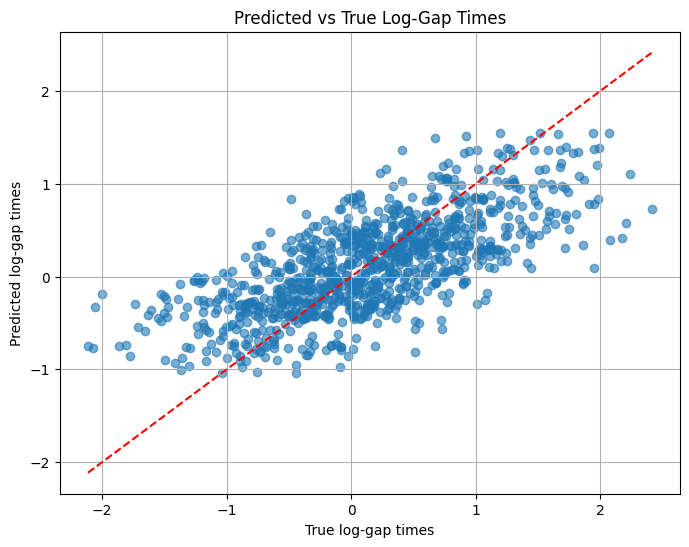

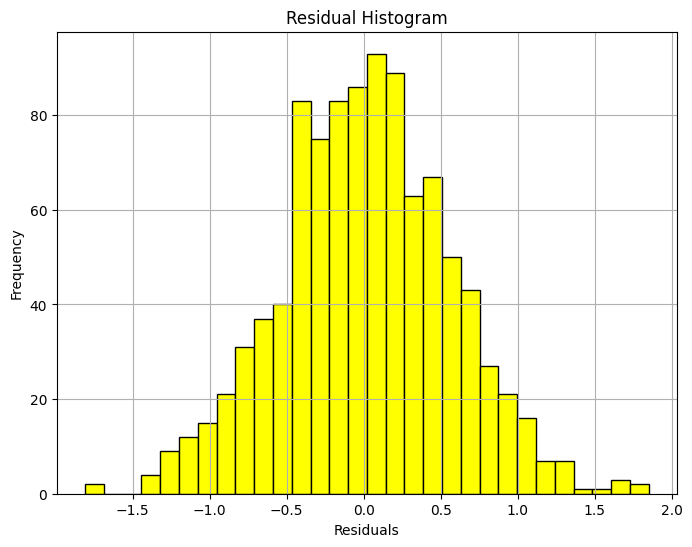

In [118]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 1. Dataset
# ===============================
class RecurrentGapDataset(Dataset):
    def __init__(self, X, G_list):
        """
        X: np.array of shape (n_subjects, n_covariates)
        G_list: list of arrays of gap times per subject
        """
        self.X = torch.tensor(X, dtype=torch.float32)
        self.G_list = G_list

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        G = self.G_list[idx]
        log_G = torch.tensor(np.log(G), dtype=torch.float32)
        prev_log_G = torch.zeros_like(log_G)
        prev_log_G[1:] = log_G[:-1]
        return self.X[idx], prev_log_G, log_G

def collate_fn(batch):
    cov_batch = torch.stack([b[0] for b in batch])
    prev_log_batch = pad_sequence([b[1] for b in batch], batch_first=True, padding_value=0.0)
    log_batch = pad_sequence([b[2] for b in batch], batch_first=True, padding_value=0.0)
    lengths = torch.tensor([len(b[2]) for b in batch])
    return cov_batch, prev_log_batch, log_batch, lengths

# ===============================
# 2. Model
# ===============================
class RNN_AFT(nn.Module):
    def __init__(self, cov_dim, hidden_dim=32):
        super().__init__()
        self.input_dim = cov_dim + 1  # covariates + previous log-gap
        self.hidden_dim = hidden_dim
        self.rnn = nn.GRU(input_size=self.input_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, X, prev_log_gaps):
        batch_size, seq_len = prev_log_gaps.shape
        # Expand covariates along sequence dimension
        X_seq = X.unsqueeze(1).repeat(1, seq_len, 1)
        inp = torch.cat([X_seq, prev_log_gaps.unsqueeze(-1)], dim=-1)
        output, _ = self.rnn(inp)
        pred = self.fc(output).squeeze(-1)
        return pred

# ===============================
# 3. Training
# ===============================
def train_model(model, dataloader, epochs=50, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss(reduction='none')
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for cov, prev_log_gaps, log_gaps, lengths in dataloader:
            optimizer.zero_grad()
            pred = model(cov, prev_log_gaps)
            mask = torch.arange(log_gaps.size(1))[None, :] < lengths[:, None]
            loss = criterion(pred, log_gaps)
            loss = (loss * mask).sum() / mask.sum()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(dataloader):.4f}")

# ===============================
# 4. Evaluation
# ===============================
def evaluate_model(model, dataloader):
    model.eval()
    preds_all, trues_all = [], []
    with torch.no_grad():
        for cov, prev_log_gaps, log_gaps, lengths in dataloader:
            pred = model(cov, prev_log_gaps)
            for i, L in enumerate(lengths):
                preds_all.extend(pred[i,:L].cpu().numpy())
                trues_all.extend(log_gaps[i,:L].cpu().numpy())
    return np.array(preds_all), np.array(trues_all)

# ===============================
# 5. Simulate some data
# ===============================
np.random.seed(42)
n_subjects = 100
n_cov = 3
X = np.random.normal(size=(n_subjects, n_cov))

G_list = []
for i in range(n_subjects):
    m_i = np.random.randint(5, 15)  # variable number of events per subject
    beta = np.array([0.5, -0.3, 0.2])
    fX = X[i] @ beta
    eps = np.random.normal(scale=0.5, size=m_i)
    G = np.exp(fX + eps)
    G_list.append(G)

dataset = RecurrentGapDataset(X, G_list)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)

# ===============================
# 6. Train
# ===============================
model = RNN_AFT(cov_dim=X.shape[1], hidden_dim=32)
train_model(model, dataloader, epochs=20, lr=1e-3)

# ===============================
# 7. Evaluate
# ===============================
preds, trues = evaluate_model(model, dataloader)

# ===============================
# 8. Plots
# ===============================
plt.figure(figsize=(8,6))
plt.scatter(trues, preds, alpha=0.6)
plt.plot([trues.min(), trues.max()], [trues.min(), trues.max()], 'r--')
plt.xlabel("True log-gap times")
plt.ylabel("Predicted log-gap times")
plt.title("Predicted vs True Log-Gap Times")
plt.grid(True)
plt.show()

# Residual histogram
residuals = trues - preds
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=30, color='yellow', edgecolor='k')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Histogram")
plt.grid(True)
plt.show()

In [8]:
# ===============================
# 9. Comparative Table: Mean True vs Predicted Gap Times per Subject
# ===============================
import pandas as pd

model.eval()
subject_summary = []

with torch.no_grad():
    for i, (cov, prev_log_gaps, log_gaps) in enumerate(zip(dataset.X,
                                                           [torch.tensor(g) for g in [b[1] for b in dataset]],
                                                           [torch.tensor(g) for g in [b[2] for b in dataset]])):
        cov = cov.unsqueeze(0)  # add batch dimension
        prev_log_gaps = prev_log_gaps.unsqueeze(0)
        log_gaps = log_gaps.unsqueeze(0)
        pred_log_gaps = model(cov, prev_log_gaps).squeeze(0).numpy()
        true_gaps = np.exp(log_gaps.squeeze(0).numpy())
        pred_gaps = np.exp(pred_log_gaps)
        subject_summary.append({
            "Subject": i+1,
            "Num_Events": len(true_gaps),
            "Mean_True_Gap": np.mean(true_gaps),
            "Mean_Pred_Gap": np.mean(pred_gaps)
        })

df_summary = pd.DataFrame(subject_summary)
print(df_summary.head(10))  # show first 10 subjects

# Optional: Save to CSV
df_summary.to_csv("subject_gap_comparison.csv", index=False)


   Subject  Num_Events  Mean_True_Gap  Mean_Pred_Gap
0        1          13       1.917593       1.600495
1        2           5       3.744813       1.982133
2        3           7       1.962530       1.518889
3        4           9       1.562145       1.340082
4        5           6       1.432839       1.332220
5        6          14       1.161333       1.116860
6        7           7       1.656762       1.371213
7        8          13       0.893964       0.685113
8        9           9       0.557216       0.624703
9       10           6       1.602849       1.299138


/tmp/ipython-input-157133757.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  [torch.tensor(g) for g in [b[1] for b in dataset]],
/tmp/ipython-input-157133757.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  [torch.tensor(g) for g in [b[2] for b in dataset]])):


In [9]:
# ===============================
# 9. Comparative Table: True vs Predicted Gap Times per Gap
# ===============================
import pandas as pd

model.eval()
records = []

with torch.no_grad():
    for i, (cov, prev_log_gaps, log_gaps, length) in enumerate(dataloader):
        # Batch evaluation
        pred_log_gaps = model(cov, prev_log_gaps)  # shape: [batch, seq_len]
        for b in range(cov.shape[0]):
            L = length[b]
            true_gaps = np.exp(log_gaps[b, :L].cpu().numpy())
            pred_gaps = np.exp(pred_log_gaps[b, :L].cpu().numpy())
            for j in range(L):
                records.append({
                    "Subject": i * dataloader.batch_size + b + 1,
                    "Event": j + 1,
                    "True_Gap": true_gaps[j],
                    "Predicted_Gap": pred_gaps[j]
                })

df_gapwise = pd.DataFrame(records)
print(df_gapwise.head(20))  # show first 20 rows

# Optional: Save full table to CSV
df_gapwise.to_csv("gapwise_comparison.csv", index=False)


    Subject  Event  True_Gap  Predicted_Gap
0         1      1  0.268335       0.809453
1         1      2  0.307836       0.605887
2         1      3  0.505612       0.514675
3         1      4  0.325577       0.483733
4         1      5  1.015738       0.457854
5         1      6  0.274434       0.476571
6         1      7  0.480878       0.452550
7         2      1  1.386632       1.279869
8         2      2  0.912159       1.490332
9         2      3  5.743118       1.591699
10        2      4  1.633838       1.876204
11        2      5  1.597256       1.888427
12        3      1  0.618260       0.973612
13        3      2  1.150726       0.861940
14        3      3  0.631282       0.837337
15        3      4  0.675822       0.786947
16        3      5  0.597691       0.763193
17        3      6  0.896154       0.744951
18        3      7  0.520212       0.760023
19        3      8  1.209123       0.739594


Epoch 1/20, Loss: 0.8367
Epoch 2/20, Loss: 0.6768
Epoch 3/20, Loss: 0.6105
Epoch 4/20, Loss: 0.5928
Epoch 5/20, Loss: 0.5357
Epoch 6/20, Loss: 0.5096
Epoch 7/20, Loss: 0.4547
Epoch 8/20, Loss: 0.4365
Epoch 9/20, Loss: 0.4277
Epoch 10/20, Loss: 0.4048
Epoch 11/20, Loss: 0.3961
Epoch 12/20, Loss: 0.3753
Epoch 13/20, Loss: 0.3756
Epoch 14/20, Loss: 0.3829
Epoch 15/20, Loss: 0.3777
Epoch 16/20, Loss: 0.3812
Epoch 17/20, Loss: 0.3659
Epoch 18/20, Loss: 0.4178
Epoch 19/20, Loss: 0.3555
Epoch 20/20, Loss: 0.3660


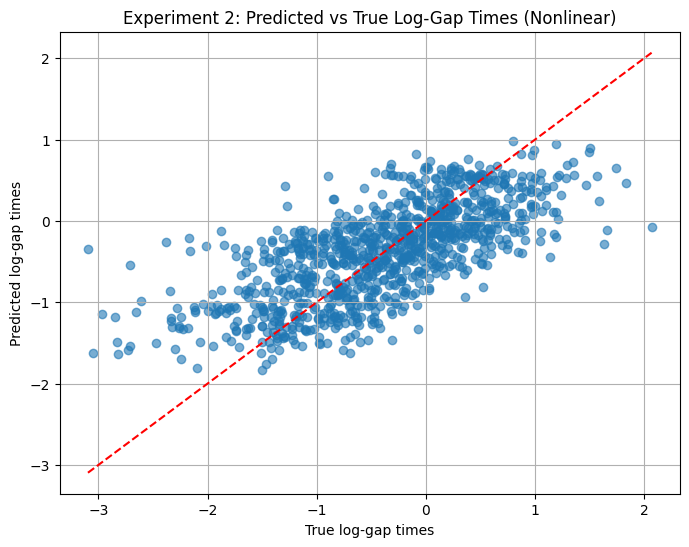

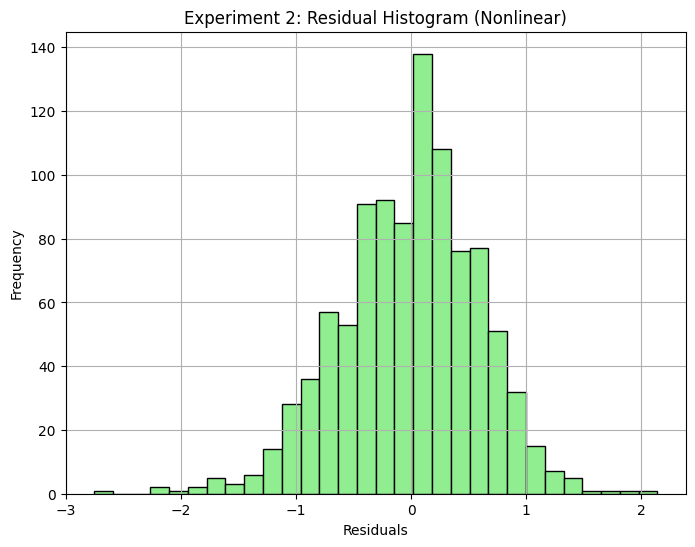

In [10]:
# ===============================
# Experiment 2: Nonlinear Covariate Effects
# ===============================
np.random.seed(123)
n_subjects = 100
n_cov = 3
X = np.random.normal(size=(n_subjects, n_cov))

G_list_nonlinear = []
for i in range(n_subjects):
    m_i = np.random.randint(5, 15)
    # Nonlinear function of covariates
    fX = 0.5*X[i,0] - 0.3*X[i,1]**2 + 0.2*np.sin(np.pi*X[i,2])
    eps = np.random.normal(scale=0.5, size=m_i)
    G = np.exp(fX + eps)
    G_list_nonlinear.append(G)

dataset2 = RecurrentGapDataset(X, G_list_nonlinear)
dataloader2 = DataLoader(dataset2, batch_size=16, shuffle=True, collate_fn=collate_fn)

# ===============================
# Train model on nonlinear data
# ===============================
model2 = RNN_AFT(cov_dim=X.shape[1], hidden_dim=32)
train_model(model2, dataloader2, epochs=20, lr=1e-3)

# ===============================
# Evaluate
# ===============================
preds2, trues2 = evaluate_model(model2, dataloader2)

# ===============================
# Plots
# ===============================
plt.figure(figsize=(8,6))
plt.scatter(trues2, preds2, alpha=0.6)
plt.plot([trues2.min(), trues2.max()], [trues2.min(), trues2.max()], 'r--')
plt.xlabel("True log-gap times")
plt.ylabel("Predicted log-gap times")
plt.title("Experiment 2: Predicted vs True Log-Gap Times (Nonlinear)")
plt.grid(True)
plt.savefig("pred_vs_true_nonlinear.png")
plt.show()

residuals2 = trues2 - preds2
plt.figure(figsize=(8,6))
plt.hist(residuals2, bins=30, color='lightgreen', edgecolor='k')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Experiment 2: Residual Histogram (Nonlinear)")
plt.grid(True)
plt.savefig("residual_hist_nonlinear.png")
plt.show()


Epoch 1/20, Loss: 0.6073
Epoch 2/20, Loss: 0.5042
Epoch 3/20, Loss: 0.4652
Epoch 4/20, Loss: 0.4105
Epoch 5/20, Loss: 0.3756
Epoch 6/20, Loss: 0.3330
Epoch 7/20, Loss: 0.3264
Epoch 8/20, Loss: 0.2995
Epoch 9/20, Loss: 0.3103
Epoch 10/20, Loss: 0.3086
Epoch 11/20, Loss: 0.2927
Epoch 12/20, Loss: 0.2980
Epoch 13/20, Loss: 0.2864
Epoch 14/20, Loss: 0.2921
Epoch 15/20, Loss: 0.2816
Epoch 16/20, Loss: 0.2933
Epoch 17/20, Loss: 0.2933
Epoch 18/20, Loss: 0.2718
Epoch 19/20, Loss: 0.2857
Epoch 20/20, Loss: 0.2781


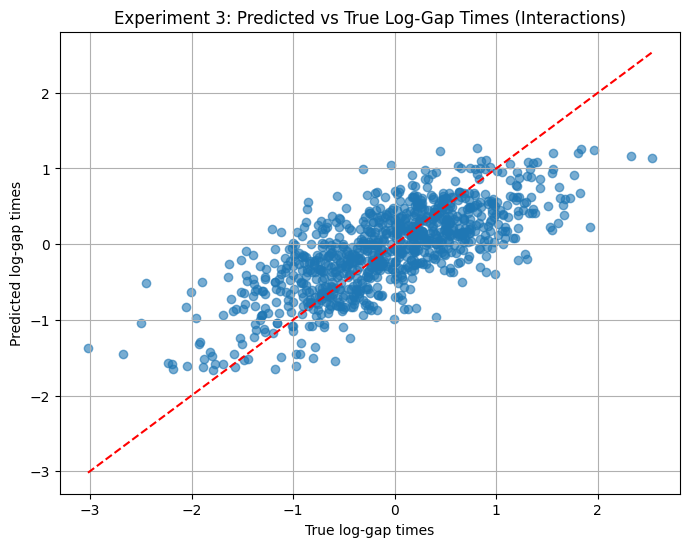

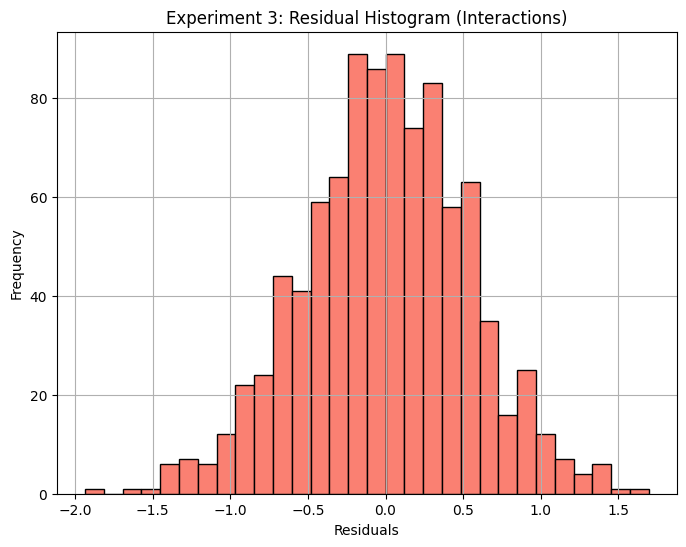

In [13]:
# ===============================
# Experiment 3: Interaction Effects
# ===============================
np.random.seed(456)
n_subjects = 100
n_cov = 3
X = np.random.normal(size=(n_subjects, n_cov))

G_list_interaction = []
for i in range(n_subjects):
    m_i = np.random.randint(5, 15)
    # Linear + interaction term between covariates
    fX = 0.5*X[i,0] - 0.3*X[i,1] + 0.2*X[i,0]*X[i,2]
    eps = np.random.normal(scale=0.5, size=m_i)
    G = np.exp(fX + eps)
    G_list_interaction.append(G)

dataset3 = RecurrentGapDataset(X, G_list_interaction)
dataloader3 = DataLoader(dataset3, batch_size=16, shuffle=True, collate_fn=collate_fn)

# ===============================
# Train model on interaction data
# ===============================
model3 = RNN_AFT(cov_dim=X.shape[1], hidden_dim=32)
train_model(model3, dataloader3, epochs=20, lr=1e-3)

# ===============================
# Evaluate
# ===============================
preds3, trues3 = evaluate_model(model3, dataloader3)

# ===============================
# Plots
# ===============================
plt.figure(figsize=(8,6))
plt.scatter(trues3, preds3, alpha=0.6)
plt.plot([trues3.min(), trues3.max()], [trues3.min(), trues3.max()], 'r--')
plt.xlabel("True log-gap times")
plt.ylabel("Predicted log-gap times")
plt.title("Experiment 3: Predicted vs True Log-Gap Times (Interactions)")
plt.grid(True)
plt.savefig("pred_vs_true_interaction.png")
plt.show()

residuals3 = trues3 - preds3
plt.figure(figsize=(8,6))
plt.hist(residuals3, bins=30, color='salmon', edgecolor='k')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Experiment 3: Residual Histogram (Interactions)")
plt.grid(True)
plt.savefig("residual_hist_interaction.png")
plt.show()



--- Training for linear experiment ---
Epoch 1/20, Loss: 0.5566
Epoch 2/20, Loss: 0.4895
Epoch 3/20, Loss: 0.4286
Epoch 4/20, Loss: 0.3779
Epoch 5/20, Loss: 0.3795
Epoch 6/20, Loss: 0.3532
Epoch 7/20, Loss: 0.3390
Epoch 8/20, Loss: 0.3329
Epoch 9/20, Loss: 0.3186
Epoch 10/20, Loss: 0.3322
Epoch 11/20, Loss: 0.3218
Epoch 12/20, Loss: 0.3263
Epoch 13/20, Loss: 0.3207
Epoch 14/20, Loss: 0.3173
Epoch 15/20, Loss: 0.3253
Epoch 16/20, Loss: 0.3229
Epoch 17/20, Loss: 0.3045
Epoch 18/20, Loss: 0.3142
Epoch 19/20, Loss: 0.2993
Epoch 20/20, Loss: 0.3101


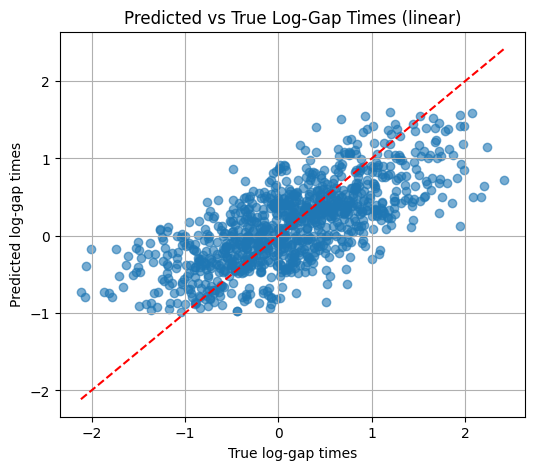

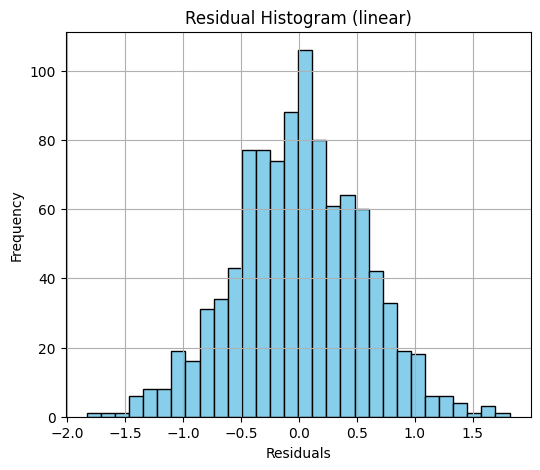


--- Training for nonlinear experiment ---
Epoch 1/20, Loss: 0.7889
Epoch 2/20, Loss: 0.6899
Epoch 3/20, Loss: 0.5863
Epoch 4/20, Loss: 0.5697
Epoch 5/20, Loss: 0.5033
Epoch 6/20, Loss: 0.4551
Epoch 7/20, Loss: 0.4221
Epoch 8/20, Loss: 0.4173
Epoch 9/20, Loss: 0.4239
Epoch 10/20, Loss: 0.4080
Epoch 11/20, Loss: 0.4017
Epoch 12/20, Loss: 0.3954
Epoch 13/20, Loss: 0.3893
Epoch 14/20, Loss: 0.3852
Epoch 15/20, Loss: 0.3935
Epoch 16/20, Loss: 0.3966
Epoch 17/20, Loss: 0.3732
Epoch 18/20, Loss: 0.3788
Epoch 19/20, Loss: 0.3876
Epoch 20/20, Loss: 0.3833


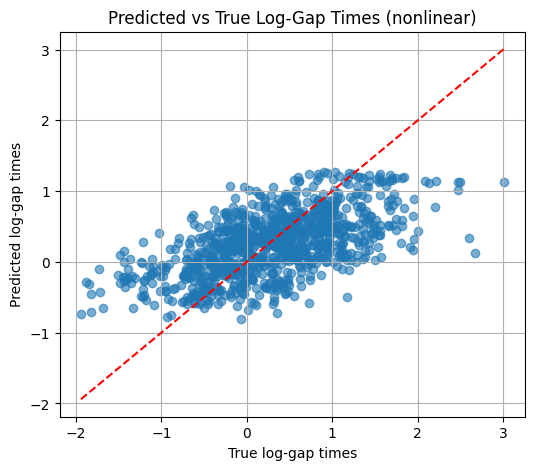

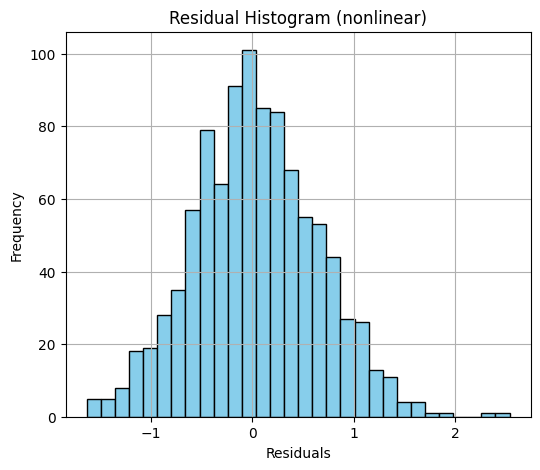


--- Training for interaction experiment ---
Epoch 1/20, Loss: 0.7075
Epoch 2/20, Loss: 0.5972
Epoch 3/20, Loss: 0.5832
Epoch 4/20, Loss: 0.5389
Epoch 5/20, Loss: 0.4712
Epoch 6/20, Loss: 0.4185
Epoch 7/20, Loss: 0.3874
Epoch 8/20, Loss: 0.3950
Epoch 9/20, Loss: 0.3604
Epoch 10/20, Loss: 0.3597
Epoch 11/20, Loss: 0.3573
Epoch 12/20, Loss: 0.3712
Epoch 13/20, Loss: 0.3605
Epoch 14/20, Loss: 0.3410
Epoch 15/20, Loss: 0.3535
Epoch 16/20, Loss: 0.3329
Epoch 17/20, Loss: 0.3401
Epoch 18/20, Loss: 0.3461
Epoch 19/20, Loss: 0.3430
Epoch 20/20, Loss: 0.3343


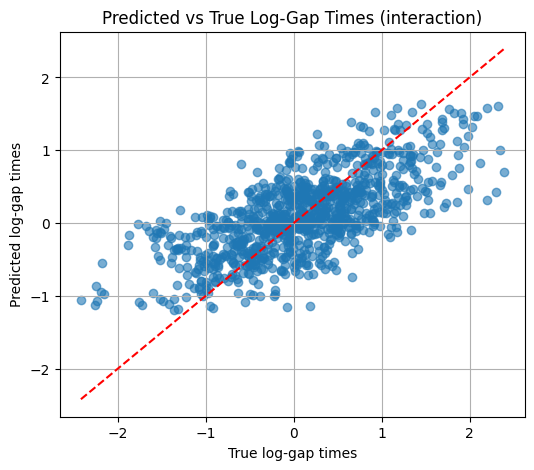

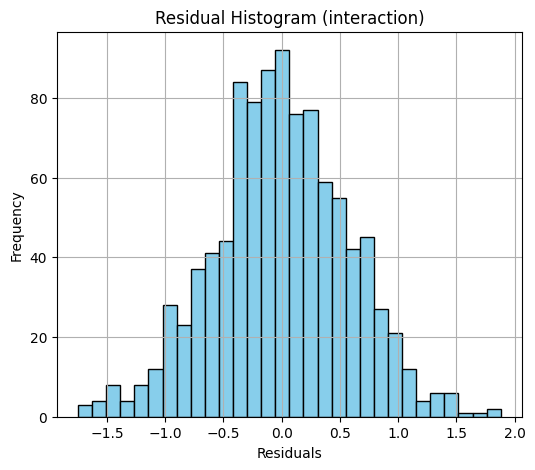

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Dataset
# ===============================
class RecurrentGapDataset(Dataset):
    def __init__(self, X, G_list):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.G_list = G_list

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        G = self.G_list[idx]
        log_G = torch.tensor(np.log(G), dtype=torch.float32)
        prev_log_G = torch.zeros_like(log_G)
        prev_log_G[1:] = log_G[:-1]
        return self.X[idx], prev_log_G, log_G

def collate_fn(batch):
    cov_batch = torch.stack([b[0] for b in batch])
    prev_log_batch = pad_sequence([b[1] for b in batch], batch_first=True, padding_value=0.0)
    log_batch = pad_sequence([b[2] for b in batch], batch_first=True, padding_value=0.0)
    lengths = torch.tensor([len(b[2]) for b in batch])
    return cov_batch, prev_log_batch, log_batch, lengths

# ===============================
# Model
# ===============================
class RNN_AFT(nn.Module):
    def __init__(self, cov_dim, hidden_dim=32):
        super().__init__()
        self.input_dim = cov_dim + 1
        self.hidden_dim = hidden_dim
        self.rnn = nn.GRU(input_size=self.input_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, X, prev_log_gaps):
        batch_size, seq_len = prev_log_gaps.shape
        X_seq = X.unsqueeze(1).repeat(1, seq_len, 1)
        inp = torch.cat([X_seq, prev_log_gaps.unsqueeze(-1)], dim=-1)
        output, _ = self.rnn(inp)
        pred = self.fc(output).squeeze(-1)
        return pred

# ===============================
# Training
# ===============================
def train_model(model, dataloader, epochs=20, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss(reduction='none')
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for cov, prev_log_gaps, log_gaps, lengths in dataloader:
            optimizer.zero_grad()
            pred = model(cov, prev_log_gaps)
            mask = torch.arange(log_gaps.size(1))[None, :] < lengths[:, None]
            loss = criterion(pred, log_gaps)
            loss = (loss * mask).sum() / mask.sum()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(dataloader):.4f}")

# ===============================
# Evaluation
# ===============================
def evaluate_model(model, dataloader):
    model.eval()
    preds_all, trues_all = [], []
    with torch.no_grad():
        for cov, prev_log_gaps, log_gaps, lengths in dataloader:
            pred = model(cov, prev_log_gaps)
            for i, L in enumerate(lengths):
                preds_all.extend(pred[i,:L].cpu().numpy())
                trues_all.extend(log_gaps[i,:L].cpu().numpy())
    return np.array(preds_all), np.array(trues_all)

# ===============================
# Simulation Helper
# ===============================
def simulate_data(n_subjects, n_cov, experiment='linear'):
    np.random.seed(42)
    X = np.random.normal(size=(n_subjects, n_cov))
    G_list = []

    for i in range(n_subjects):
        m_i = np.random.randint(5, 15)
        if experiment == 'linear':
            fX = 0.5*X[i,0] - 0.3*X[i,1] + 0.2*X[i,2]
        elif experiment == 'nonlinear':
            fX = 0.5*X[i,0] + 0.2*X[i,1]**2 + 0.3*np.sin(np.pi*X[i,2])
        elif experiment == 'interaction':
            fX = 0.5*X[i,0] - 0.3*X[i,1] + 0.2*X[i,0]*X[i,2]
        eps = np.random.normal(scale=0.5, size=m_i)
        G = np.exp(fX + eps)
        G_list.append(G)
    return X, G_list

# ===============================
# Run experiments
# ===============================
experiments = ['linear', 'nonlinear', 'interaction']
results = {}

for exp in experiments:
    print(f"\n--- Training for {exp} experiment ---")
    X, G_list = simulate_data(100, 3, experiment=exp)
    dataset = RecurrentGapDataset(X, G_list)
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)

    model = RNN_AFT(cov_dim=X.shape[1], hidden_dim=32)
    train_model(model, dataloader, epochs=20, lr=1e-3)

    preds, trues = evaluate_model(model, dataloader)
    results[exp] = {'preds': preds, 'trues': trues}

    # Plot predicted vs true
    plt.figure(figsize=(6,5))
    plt.scatter(trues, preds, alpha=0.6)
    plt.plot([trues.min(), trues.max()], [trues.min(), trues.max()], 'r--')
    plt.xlabel("True log-gap times")
    plt.ylabel("Predicted log-gap times")
    plt.title(f"Predicted vs True Log-Gap Times ({exp})")
    plt.grid(True)
    plt.show()

    # Residuals
    residuals = trues - preds
    plt.figure(figsize=(6,5))
    plt.hist(residuals, bins=30, color='skyblue', edgecolor='k')
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title(f"Residual Histogram ({exp})")
    plt.grid(True)
    plt.show()


Censored Gap Times Settings

In [116]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# Simulate data
n_subjects = 50
n_cov = 3

X = np.random.normal(size=(n_subjects, n_cov))
G_list = []
delta_list = []


for i in range(n_subjects):
    m_i = np.random.randint(5, 10)
    beta = np.array([0.5, -0.3, 0.2])
    fX = X[i] @ beta
    eps = np.random.normal(scale=0.5, size=m_i)
    G = np.exp(fX + eps)

    # Introduce censoring (30% chance per event)
    delta = np.random.binomial(1, 0.7, size=m_i)

    G_list.append(G)
    delta_list.append(delta)

"""
for i in range(n_subjects):
    m_i = np.random.randint(5, 10)
    beta = np.array([0.5, -0.3, 0.2])
    fX = 0.5*X[i,0] - 0.3*X[i,1]**2 + 0.2*np.sin(np.pi*X[i,2])
    eps = np.random.normal(scale=0.5, size=m_i)
    G = np.exp(fX + eps)

    # Introduce censoring (30% chance per event)
    delta = np.random.binomial(1, 0.7, size=m_i)

    G_list.append(G)
    delta_list.append(delta)
"""

for i in range(n_subjects):
    m_i = np.random.randint(5, 10)
    beta = np.array([0.5, -0.3, 0.2])
    fX = 0.5*X[i,0] - 0.3*X[i,1] + 0.2*X[i,0]*X[i,2]
    eps = np.random.normal(scale=0.5, size=m_i)
    G = np.exp(fX + eps)

    # Introduce censoring (30% chance per event)
    delta = np.random.binomial(1, 0.7, size=m_i)

    G_list.append(G)
    delta_list.append(delta)


# Dataset
class CensoredGapDataset(Dataset):
    def __init__(self, X, G_list, delta_list):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.G_list = G_list
        self.delta_list = delta_list

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        G = self.G_list[idx]
        log_G = torch.tensor(np.log(G), dtype=torch.float32)
        prev_log_G = torch.zeros_like(log_G)
        prev_log_G[1:] = log_G[:-1]
        delta = torch.tensor(self.delta_list[idx], dtype=torch.float32)
        return self.X[idx], prev_log_G, log_G, delta

def collate_fn(batch):
    cov_batch = torch.stack([b[0] for b in batch])
    prev_log_batch = pad_sequence([b[1] for b in batch], batch_first=True, padding_value=0.0)
    log_batch = pad_sequence([b[2] for b in batch], batch_first=True, padding_value=0.0)
    delta_batch = pad_sequence([b[3] for b in batch], batch_first=True, padding_value=0.0)
    lengths = torch.tensor([len(b[2]) for b in batch])
    return cov_batch, prev_log_batch, log_batch, delta_batch, lengths

dataloader = DataLoader(CensoredGapDataset(X,G_list,delta_list), batch_size=8, shuffle=True, collate_fn=collate_fn)

# Model
class RNN_AFT(nn.Module):
    def __init__(self, cov_dim, hidden_dim=32):
        super().__init__()
        self.rnn = nn.GRU(input_size=cov_dim+1, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, X, prev_log_gaps):
        seq_len = prev_log_gaps.shape[1]
        X_seq = X.unsqueeze(1).repeat(1, seq_len, 1)
        inp = torch.cat([X_seq, prev_log_gaps.unsqueeze(-1)], dim=-1)
        out, _ = self.rnn(inp)
        return self.fc(out).squeeze(-1)




In [104]:
def train_naive(model, dataloader, epochs=20, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss(reduction='none')
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for cov, prev_log, log_g, delta, lengths in dataloader:
            optimizer.zero_grad()
            pred = model(cov, prev_log)
            mask = torch.arange(log_g.size(1))[None,:] < lengths[:,None]
            mask = mask & (delta.bool())  # only observed
            loss = (criterion(pred, log_g)*mask).sum()/mask.sum()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Naive Epoch {epoch+1}: {total_loss/len(dataloader):.4f}")





In [106]:
#!pip install lifelines
from lifelines import KaplanMeierFitter

class RecurrentGapDatasetIPCW(Dataset):
    def __init__(self, X, G_list, delta_list, weights_list):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.G_list = G_list
        self.delta_list = delta_list
        self.weights_list = weights_list

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        G = self.G_list[idx]
        log_G = torch.tensor(np.log(G), dtype=torch.float32)
        prev_log_G = torch.zeros_like(log_G)
        prev_log_G[1:] = log_G[:-1]

        delta = torch.tensor(self.delta_list[idx], dtype=torch.float32)
        weights = torch.tensor(self.weights_list[idx], dtype=torch.float32)

        # Make sure to return all five elements
        return self.X[idx], prev_log_G, log_G, delta, weights


# Estimate censoring survival with Kaplan-Meier
def compute_ipcw_weights(delta_list):
    all_gaps = np.concatenate(G_list)
    all_delta = np.concatenate(delta_list)
    from lifelines import KaplanMeierFitter
    kmf = KaplanMeierFitter()
    kmf.fit(all_gaps, event_observed=all_delta)
    weights_list = []
    for G, delta in zip(G_list, delta_list):
        S_c = kmf.survival_function_at_times(G).values
        weights = delta / S_c
        weights_list.append(weights)
    return weights_list

ipcw_weights_list = compute_ipcw_weights(delta_list)

def collate_fn_ipcw(batch):
    cov_batch = torch.stack([b[0] for b in batch])
    prev_log_batch = pad_sequence([b[1] for b in batch], batch_first=True, padding_value=0.0)
    log_batch = pad_sequence([b[2] for b in batch], batch_first=True, padding_value=0.0)
    delta_batch = pad_sequence([b[3] for b in batch], batch_first=True, padding_value=0.0)
    weights_batch = pad_sequence([b[4] for b in batch], batch_first=True, padding_value=0.0)
    lengths = torch.tensor([len(b[2]) for b in batch])
    return cov_batch, prev_log_batch, log_batch, delta_batch, weights_batch, lengths



dataloader_ipcw = DataLoader(CensoredGapDataset(X,G_list,delta_list), batch_size=8, shuffle=True, collate_fn=collate_fn_ipcw)

def train_ipcw(model, dataloader, epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss(reduction='none')
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for cov, prev_log_gaps, log_g, delta, weights, lengths in dataloader:
            optimizer.zero_grad()
            pred = model(cov, prev_log_gaps)
            mask = torch.arange(log_g.size(1))[None,:] < lengths[:,None]
            mask = mask & delta.bool()
            loss = (criterion(pred, log_g) * mask * weights).sum() / mask.sum()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(dataloader):.4f}")


In [107]:
def train_gehan(model, dataloader, epochs=20, lr=1e-3, alpha=0.1):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for cov, prev_log, log_g, delta, lengths in dataloader:
            optimizer.zero_grad()
            pred = model(cov, prev_log)
            loss = 0
            for i in range(pred.shape[0]):
                L = lengths[i]
                for j in range(L):
                    if delta[i,j]==0: continue
                    e_ij = log_g[i,j]-pred[i,j]
                    for k in range(L):
                        if i==k: continue
                        e_kl = log_g[i,k]-pred[i,k]
                        loss += max(0,e_ij-e_kl+alpha)
            loss /= pred.shape[0]
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Gehan Epoch {epoch+1}: {total_loss/len(dataloader):.4f}")


In [108]:
# Rank-based Gehan
model3 = RNN_AFT(n_cov)
train_gehan(model3, dataloader, epochs=10)


Gehan Epoch 1: 10.0695
Gehan Epoch 2: 9.9776
Gehan Epoch 3: 9.5423
Gehan Epoch 4: 9.7419
Gehan Epoch 5: 9.3913
Gehan Epoch 6: 10.4052
Gehan Epoch 7: 9.3648
Gehan Epoch 8: 9.6455
Gehan Epoch 9: 9.5735
Gehan Epoch 10: 9.6624


In [110]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 1. Simulate censored recurrent gap-time data
# ===============================
np.random.seed(42)
n_subjects = 50
n_cov = 3

X = np.random.normal(size=(n_subjects, n_cov))

G_list = []
delta_list = []  # 1 = observed, 0 = censored
for i in range(n_subjects):
    m_i = np.random.randint(5, 12)
    beta = np.array([0.5, -0.3, 0.2])
    fX = X[i] @ beta
    eps = np.random.normal(scale=0.5, size=m_i)
    G = np.exp(fX + eps)

    # Random censoring
    C = np.random.exponential(scale=10, size=m_i)
    observed = G <= C
    G_obs = np.minimum(G, C)

    G_list.append(G_obs)
    delta_list.append(observed.astype(float))

# ===============================
# 2. IPCW weights (simple)
# ===============================
# For simplicity, we'll use weights = 1 for observed, 0 for censored
weights_list = [d for d in delta_list]

# ===============================
# 3. Dataset
# ===============================
class RecurrentGapDatasetIPCW(Dataset):
    def __init__(self, X, G_list, delta_list, weights_list):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.G_list = G_list
        self.delta_list = delta_list
        self.weights_list = weights_list

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        G = self.G_list[idx]
        log_G = torch.tensor(np.log(G), dtype=torch.float32)
        prev_log_G = torch.zeros_like(log_G)
        prev_log_G[1:] = log_G[:-1]

        delta = torch.tensor(self.delta_list[idx], dtype=torch.float32)
        weights = torch.tensor(self.weights_list[idx], dtype=torch.float32)

        return self.X[idx], prev_log_G, log_G, delta, weights

def collate_fn_ipcw(batch):
    cov_batch = torch.stack([b[0] for b in batch])
    prev_log_batch = pad_sequence([b[1] for b in batch], batch_first=True, padding_value=0.0)
    log_batch = pad_sequence([b[2] for b in batch], batch_first=True, padding_value=0.0)
    delta_batch = pad_sequence([b[3] for b in batch], batch_first=True, padding_value=0.0)
    weights_batch = pad_sequence([b[4] for b in batch], batch_first=True, padding_value=0.0)
    lengths = torch.tensor([len(b[2]) for b in batch])
    return cov_batch, prev_log_batch, log_batch, delta_batch, weights_batch, lengths

dataset_ipcw = RecurrentGapDatasetIPCW(X, G_list, delta_list, weights_list)
dataloader_ipcw = DataLoader(dataset_ipcw, batch_size=8, shuffle=True, collate_fn=collate_fn_ipcw)

# ===============================
# 4. Model
# ===============================
class RNN_AFT(nn.Module):
    def __init__(self, cov_dim, hidden_dim=32):
        super().__init__()
        self.input_dim = cov_dim + 1
        self.hidden_dim = hidden_dim
        self.rnn = nn.GRU(input_size=self.input_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, X, prev_log_gaps):
        batch_size, seq_len = prev_log_gaps.shape
        X_seq = X.unsqueeze(1).repeat(1, seq_len, 1)
        inp = torch.cat([X_seq, prev_log_gaps.unsqueeze(-1)], dim=-1)
        output, _ = self.rnn(inp)
        pred = self.fc(output).squeeze(-1)
        return pred

# ===============================
# 5. Training Functions
# ===============================
def train_naive(model, dataloader, epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss(reduction='none')
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for cov, prev_log, log_g, delta, weights, lengths in dataloader:
            optimizer.zero_grad()
            pred = model(cov, prev_log)
            mask = torch.arange(log_g.size(1))[None, :] < lengths[:, None]
            loss = criterion(pred, log_g)
            loss = (loss * mask).sum() / mask.sum()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Naive Epoch {epoch+1}: {epoch_loss/len(dataloader):.4f}")

def train_ipcw(model, dataloader, epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss(reduction='none')
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for cov, prev_log, log_g, delta, weights, lengths in dataloader:
            optimizer.zero_grad()
            pred = model(cov, prev_log)
            mask = torch.arange(log_g.size(1))[None, :] < lengths[:, None]
            mask = mask.bool()
            loss = (criterion(pred, log_g) * mask * weights).sum() / (mask * weights.bool()).sum()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"IPCW Epoch {epoch+1}: {epoch_loss/len(dataloader):.4f}")

# ===============================
# 6. Initialize and train models
# ===============================
n_cov = X.shape[1]

# Naive
model_naive = RNN_AFT(n_cov)
train_naive(model_naive, dataloader_ipcw, epochs=5)

# IPCW
model_ipcw = RNN_AFT(n_cov)
train_ipcw(model_ipcw, dataloader_ipcw, epochs=5)


Naive Epoch 1: 0.6206
Naive Epoch 2: 0.5716
Naive Epoch 3: 0.5242
Naive Epoch 4: 0.4816
Naive Epoch 5: 0.4667
IPCW Epoch 1: 0.5297
IPCW Epoch 2: 0.4482
IPCW Epoch 3: 0.4029
IPCW Epoch 4: 0.3646
IPCW Epoch 5: 0.3280


Gehan Epoch 1/10, Loss: 1.0010
Gehan Epoch 2/10, Loss: 0.9961
Gehan Epoch 3/10, Loss: 0.9914
Gehan Epoch 4/10, Loss: 0.9887
Gehan Epoch 5/10, Loss: 0.9776
Gehan Epoch 6/10, Loss: 0.9729
Gehan Epoch 7/10, Loss: 0.9636
Gehan Epoch 8/10, Loss: 0.9467
Gehan Epoch 9/10, Loss: 0.9348
Gehan Epoch 10/10, Loss: 0.9143
Gehan MSE: 0.8191


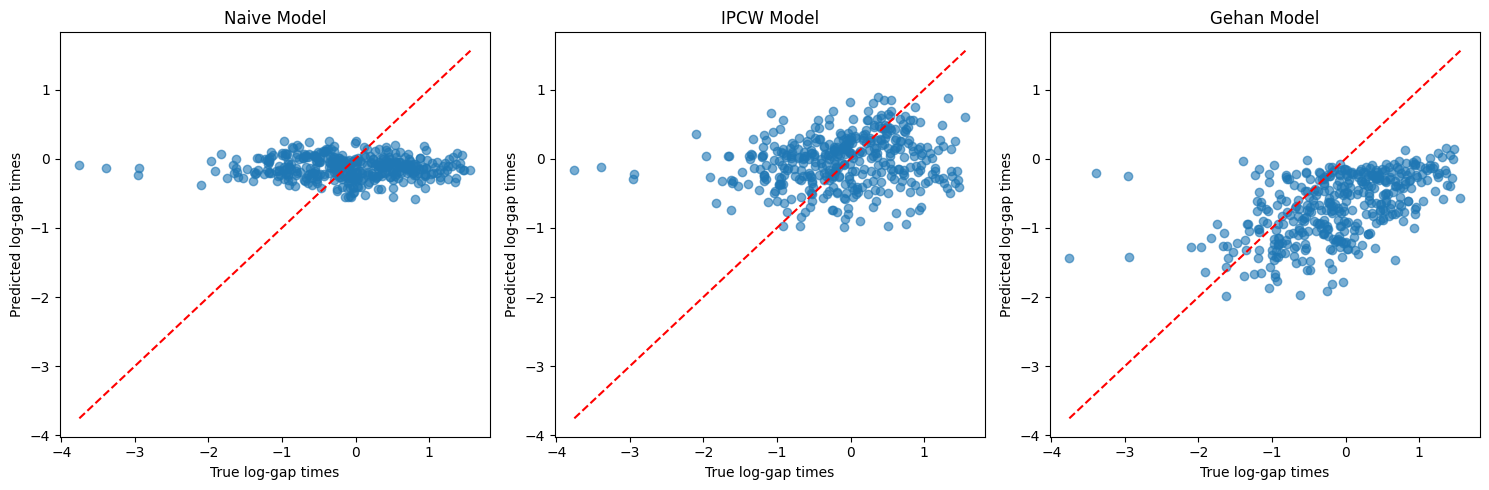

In [111]:
# ===============================
# 1. Define Gehan loss training
# ===============================
def gehan_loss(pred, log_g, lengths):
    """
    Compute Gehan loss for recurrent gap times.
    pred, log_g: [batch_size, seq_len]
    lengths: tensor with valid lengths per subject
    """
    loss = 0.0
    count = 0
    for i, L in enumerate(lengths):
        pi = pred[i, :L]
        gi = log_g[i, :L]
        for j in range(L):
            for k in range(L):
                loss += torch.clamp(1 - (pi[j] - pi[k]) * (gi[j] - gi[k]), min=0)
                count += 1
    return loss / count

def train_gehan(model, dataloader, epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for cov, prev_log, log_g, delta, weights, lengths in dataloader:
            optimizer.zero_grad()
            pred = model(cov, prev_log)
            loss = gehan_loss(pred, log_g, lengths)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Gehan Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(dataloader):.4f}")

# ===============================
# 2. Train Gehan model
# ===============================
model_gehan = RNN_AFT(n_cov, hidden_dim=32)
train_gehan(model_gehan, dataloader_ipcw, epochs=10, lr=1e-3)

# ===============================
# 3. Evaluate Gehan
# ===============================
preds_gehan, trues_gehan, mse_gehan = evaluate_model(model_gehan, dataloader_ipcw)
print(f"Gehan MSE: {mse_gehan:.4f}")

# ===============================
# 4. Comparative scatter plots
# ===============================
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.scatter(trues_naive, preds_naive, alpha=0.6)
plt.plot([trues_naive.min(), trues_naive.max()], [trues_naive.min(), trues_naive.max()], 'r--')
plt.xlabel("True log-gap times")
plt.ylabel("Predicted log-gap times")
plt.title("Naive Model")

plt.subplot(1,3,2)
plt.scatter(trues_ipcw, preds_ipcw, alpha=0.6)
plt.plot([trues_ipcw.min(), trues_ipcw.max()], [trues_ipcw.min(), trues_ipcw.max()], 'r--')
plt.xlabel("True log-gap times")
plt.ylabel("Predicted log-gap times")
plt.title("IPCW Model")

plt.subplot(1,3,3)
plt.scatter(trues_gehan, preds_gehan, alpha=0.6)
plt.plot([trues_gehan.min(), trues_gehan.max()], [trues_gehan.min(), trues_gehan.max()], 'r--')
plt.xlabel("True log-gap times")
plt.ylabel("Predicted log-gap times")
plt.title("Gehan Model")

plt.tight_layout()
plt.show()

In [112]:
import pandas as pd
import numpy as np

# ===============================
# 1. Convert log-gap predictions to actual gaps
# ===============================
true_gaps = np.concatenate(G_list)           # true per-event gaps
pred_naive_gaps = np.exp(preds_naive)       # naive predictions
pred_ipcw_gaps = np.exp(preds_ipcw)         # IPCW predictions
pred_gehan_gaps = np.exp(preds_gehan)       # Gehan predictions

# ===============================
# 2. Prepare Subject and Event columns
# ===============================
subjects = np.repeat(np.arange(1, len(G_list)+1), [len(g) for g in G_list])
events = [i+1 for g in G_list for i in range(len(g))]

# ===============================
# 3. Build comparative DataFrame
# ===============================
df_compare = pd.DataFrame({
    "Subject": subjects,
    "Event": events,
    "True_Gap": true_gaps,
    "Predicted_Naive": pred_naive_gaps,
    "Predicted_IPCW": pred_ipcw_gaps,
    "Predicted_Gehan": pred_gehan_gaps
})

# ===============================
# 4. Display first 10 rows
# ===============================
print(df_compare.head(10))


   Subject  Event  True_Gap  Predicted_Naive  Predicted_IPCW  Predicted_Gehan
0        1      1  2.071337         0.826019        0.851660         0.783172
1        1      2  2.795216         0.817721        0.788540         0.614653
2        1      3  1.703216         0.845852        0.721573         0.512217
3        1      4  2.323500         0.852830        0.675157         0.391397
4        1      5  1.659955         0.834762        0.630996         0.328684
5        1      6  0.827742         0.825019        0.602098         0.270549
6        1      7  2.570365         0.797442        1.030074         0.236889
7        1      8  0.983571         0.832747        1.059941         0.292313
8        1      9  2.195972         0.843668        1.128505         0.241627
9        1     10  0.943768         0.877857        1.129400         0.264234


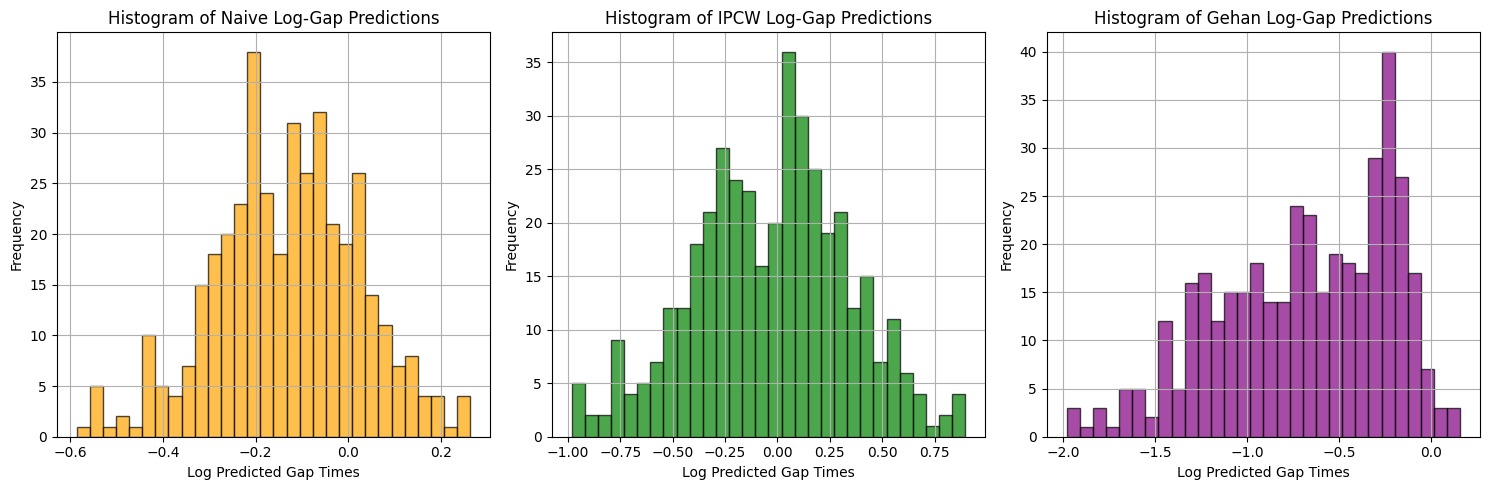

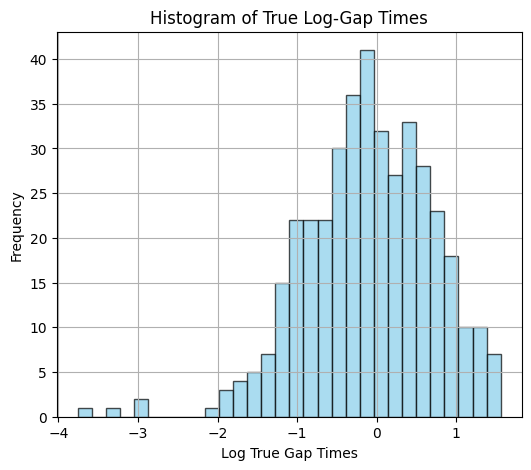

In [120]:
import matplotlib.pyplot as plt

# ===============================
# 1. Convert actual gaps to log (for plotting)
# ===============================
log_true_gaps = np.log(true_gaps)
log_pred_naive = np.log(pred_naive_gaps)
log_pred_ipcw = np.log(pred_ipcw_gaps)
log_pred_gehan = np.log(pred_gehan_gaps)

# ===============================
# 2. Plot histograms
# ===============================
plt.figure(figsize=(15,5))

plt.subplot(1,3,3)
plt.hist(log_pred_gehan, bins=30, alpha=0.7, color='purple', edgecolor='k')
plt.xlabel("Log Predicted Gap Times")
plt.ylabel("Frequency")
plt.title("Histogram of Gehan Log-Gap Predictions")
plt.grid(True)

plt.subplot(1,3,1)
plt.hist(log_pred_naive, bins=30, alpha=0.7, color='orange', edgecolor='k')
plt.xlabel("Log Predicted Gap Times")
plt.ylabel("Frequency")
plt.title("Histogram of Naive Log-Gap Predictions")
plt.grid(True)

plt.subplot(1,3,2)
plt.hist(log_pred_ipcw, bins=30, alpha=0.7, color='green', edgecolor='k')
plt.xlabel("Log Predicted Gap Times")
plt.ylabel("Frequency")
plt.title("Histogram of IPCW Log-Gap Predictions")
plt.grid(True)

plt.tight_layout()
plt.show()

# ===============================
# 3. Add Gehan as a separate figure
# ===============================
plt.figure(figsize=(6,5))
plt.hist(log_true_gaps, bins=30, alpha=0.7, color='skyblue', edgecolor='k')
plt.xlabel("Log True Gap Times")
plt.ylabel("Frequency")
plt.title("Histogram of True Log-Gap Times")
plt.grid(True)
plt.show()


In [99]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_subjects = 5      # smaller number for display
n_cov = 3
X = np.random.normal(size=(n_subjects, n_cov))

G_list = []
delta_list = []  # 1 if event observed, 0 if censored
C_max = 5.0      # maximum follow-up time (for censoring)

for i in range(n_subjects):
    m_i = np.random.randint(3, 8)  # variable number of events per subject
    beta = np.array([0.5, -0.3, 0.2])
    fX = X[i] @ beta
    eps = np.random.normal(scale=0.5, size=m_i)
    G = np.exp(fX + eps)

    # Introduce censoring
    cum_times = np.cumsum(G)
    delta = np.ones_like(G)
    censored_idx = np.where(cum_times > C_max)[0]
    if len(censored_idx) > 0:
        delta[censored_idx[0]:] = 0
        G[censored_idx[0]:] = C_max - (cum_times[censored_idx[0]-1] if censored_idx[0] > 0 else 0)

    G_list.append(G)
    delta_list.append(delta)

# Create a DataFrame to inspect
df_censored = pd.DataFrame({
    "Subject": [i+1 for i, g in enumerate(G_list) for _ in range(len(g))],
    "Event": [j+1 for g in G_list for j in range(len(g))],
    "Gap_Time": np.concatenate(G_list),
    "Observed": np.concatenate(delta_list)
})

print(df_censored)


    Subject  Event  Gap_Time  Observed
0         1      1  1.148240       1.0
1         1      2  1.165867       1.0
2         1      3  1.434242       1.0
3         1      4  1.251651       0.0
4         1      5  1.251651       0.0
5         2      1  5.000000       0.0
6         2      2  5.000000       0.0
7         2      3  5.000000       0.0
8         2      4  5.000000       0.0
9         2      5  5.000000       0.0
10        2      6  5.000000       0.0
11        3      1  1.095206       1.0
12        3      2  1.079276       1.0
13        3      3  2.559732       1.0
14        3      4  0.265786       0.0
15        3      5  0.265786       0.0
16        3      6  0.265786       0.0
17        3      7  0.265786       0.0
18        4      1  1.119222       1.0
19        4      2  1.524385       1.0
20        4      3  0.515470       1.0
21        4      4  0.706852       1.0
22        4      5  1.134071       0.0
23        4      6  1.134071       0.0
24        5      1  1.545